# QTableBot vs SmeshBot

`agents.smesh_bot.SmeshBot` is a hand-tuned heuristic AI, ported from the original
Scratch game's blocking-loop CPU opponent. `agents.qtable_bot.QTableBot` is the
opposite: a from-scratch tabular Q-learning agent with no hand-coded pursuit, attack,
or recovery logic — everything it does is learned online, one tick at a time.

This notebook plays 2000 headless matches of QTableBot (P0) against a default-config
SmeshBot (P1), reusing the *same* `QTableBot` instance throughout so its q-table
persists and grows across matches, and logs progress to MLflow every 100 matches.
The question: can a simple learner catch up to (or beat) the heuristic?

In [4]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from smeshlite.core.match import Match, MatchConfig
from agents.smesh_bot import SmeshBot
from agents.qtable_bot import QTableBot

## Agent design recap

See `agents/qtable_bot.py` for the full docstring. In short:

- **State** (504 discrete states): bucketed `dx`/`dy` to the opponent, whether we're
  airborne, whether the opponent is mid-attack/charge, which third of the platform
  we're standing on, and whether we're in hitstun.
- **Actions** (8): `NONE, LEFT, RIGHT, UP, ATTACK, LEFT+ATTACK, RIGHT+ATTACK, UP+ATTACK`.
- **Reward**: `+dmg_scale * damage dealt`, `+ko_reward` for KO'ing the opponent,
  `-death_penalty` for losing a stock — the same shaping as `SmeshLiteEnv._compute_reward`.
- **Learning**: plain tabular Q-learning, updated every tick from the *previous*
  tick's (state, action) once this tick's reward/next-state are known.

In [5]:
qtable = QTableBot()  # persists across all matches below

N_MATCHES = 2000
LOG_EVERY = 100
EPSILON_START = 0.3
EPSILON_END = 0.02


def epsilon_for(match_idx: int) -> float:
    """Linear decay from EPSILON_START to EPSILON_END over N_MATCHES."""
    t = min(match_idx / N_MATCHES, 1.0)
    return EPSILON_START + (EPSILON_END - EPSILON_START) * t

## Training loop

Each match: set `qtable.epsilon` from the decay schedule, play a fresh `Match` to
completion (QTableBot as P0, a fresh default `SmeshBot()` as P1), then record the
outcome. Every `LOG_EVERY` matches, aggregate the trailing window and log it to
MLflow as a metric step. 2000 matches should take on the order of a few minutes.

In [6]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("qtable_vs_smeshbot")

history = []
t0 = time.time()

with mlflow.start_run(run_name=f"qtable_{time.strftime('%Y%m%d_%H%M%S')}") as run:
    run_id = run.info.run_id
    mlflow.log_params({
        "alpha": qtable.alpha,
        "gamma": qtable.gamma,
        "dmg_scale": qtable.dmg_scale,
        "ko_reward": qtable.ko_reward,
        "death_penalty": qtable.death_penalty,
        "time_penalty": qtable.time_penalty,
        "n_actions": QTableBot.N_ACTIONS,
        "n_matches": N_MATCHES,
        "log_every": LOG_EVERY,
        "epsilon_start": EPSILON_START,
        "epsilon_end": EPSILON_END,
        "opponent": "SmeshBot (default params)",
    })

    for match_idx in range(1, N_MATCHES + 1):
        qtable.epsilon = epsilon_for(match_idx)

        m = Match(MatchConfig())
        m.reset(n_players=2)
        m.set_player_brain(0, qtable)
        m.set_player_brain(1, SmeshBot())
        qtable.new_episode()

        while not m.done:
            m.tick()

        history.append({
            "match": match_idx,
            "winner": m.winner,
            "frames": m.frame,
            "episode_reward": qtable.episode_reward,
            "q_table_size": qtable.q_table_size,
            "epsilon": qtable.epsilon,
        })

        if match_idx % LOG_EVERY == 0:
            recent = history[-LOG_EVERY:]
            win_rate = sum(1 for h in recent if h["winner"] == 0) / len(recent)
            avg_frames = sum(h["frames"] for h in recent) / len(recent)
            avg_reward = sum(h["episode_reward"] for h in recent) / len(recent)
            mlflow.log_metrics({
                "win_rate": win_rate,
                "avg_frames": avg_frames,
                "avg_reward": avg_reward,
                "q_table_size": qtable.q_table_size,
                "epsilon": qtable.epsilon,
            }, step=match_idx)
            print(f"match {match_idx:5d}: win_rate={win_rate:.2f} avg_reward={avg_reward:+.3f} q_table_size={qtable.q_table_size}")

print(f"done in {time.time() - t0:.1f}s")
df = pd.DataFrame(history)
df.tail()

match   100: win_rate=0.42 avg_reward=+4.402 q_table_size=309
match   200: win_rate=0.71 avg_reward=+5.743 q_table_size=327
match   300: win_rate=0.67 avg_reward=+5.374 q_table_size=329
match   400: win_rate=0.65 avg_reward=+5.753 q_table_size=334
match   500: win_rate=0.76 avg_reward=+5.952 q_table_size=335
match   600: win_rate=0.88 avg_reward=+6.472 q_table_size=337
match   700: win_rate=0.82 avg_reward=+6.043 q_table_size=342
match   800: win_rate=0.88 avg_reward=+6.396 q_table_size=343
match   900: win_rate=0.95 avg_reward=+6.622 q_table_size=343
match  1000: win_rate=0.88 avg_reward=+6.673 q_table_size=344
match  1100: win_rate=0.92 avg_reward=+6.522 q_table_size=344
match  1200: win_rate=0.98 avg_reward=+6.573 q_table_size=345
match  1300: win_rate=0.96 avg_reward=+6.220 q_table_size=346
match  1400: win_rate=0.89 avg_reward=+5.912 q_table_size=346
match  1500: win_rate=0.95 avg_reward=+6.070 q_table_size=347
match  1600: win_rate=0.91 avg_reward=+6.237 q_table_size=347
match  1

,match,winner,frames,episode_reward,q_table_size,epsilon
1995,1996,0,1808,5.19,348,0.02056
1996,1997,0,1405,4.80,348,0.02042
1997,1998,0,1214,5.09,348,0.02028
1998,1999,0,1798,6.15,348,0.02014
1999,2000,0,1682,6.86,348,0.02000


## Results

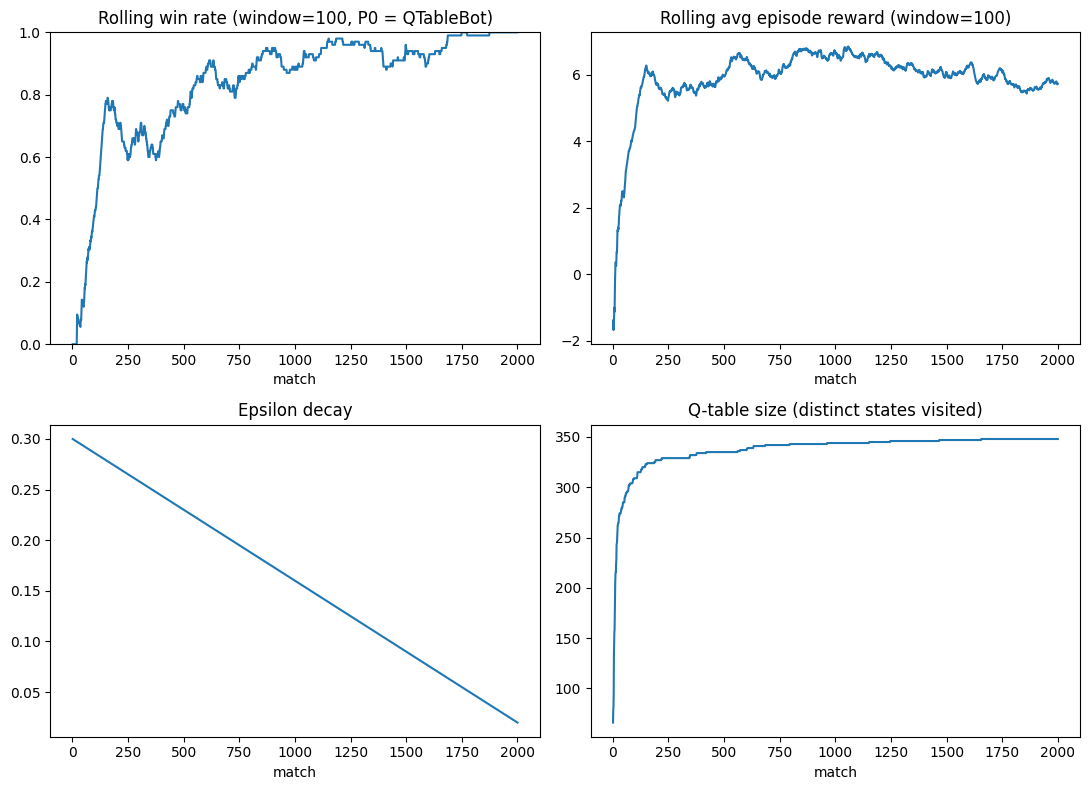

In [7]:
win_rolling = df["winner"].eq(0).rolling(100, min_periods=1).mean()
reward_rolling = df["episode_reward"].rolling(100, min_periods=1).mean()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(df["match"], win_rolling)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title("Rolling win rate (window=100, P0 = QTableBot)")
axes[0, 0].set_xlabel("match")

axes[0, 1].plot(df["match"], reward_rolling)
axes[0, 1].set_title("Rolling avg episode reward (window=100)")
axes[0, 1].set_xlabel("match")

axes[1, 0].plot(df["match"], df["epsilon"])
axes[1, 0].set_title("Epsilon decay")
axes[1, 0].set_xlabel("match")

axes[1, 1].plot(df["match"], df["q_table_size"])
axes[1, 1].set_title("Q-table size (distinct states visited)")
axes[1, 1].set_xlabel("match")

fig.tight_layout()

In [8]:
checkpoint_path = "agents/checkpoints/qtable_bot.json"
qtable.save(checkpoint_path)

with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact(checkpoint_path)

print(f"Saved Q-table ({qtable.q_table_size} states) to {checkpoint_path}")

🏃 View run qtable_20260611_184939 at: http://localhost:5000/#/experiments/2/runs/0a8b7205ebf94c999d87d3a9739ad5ac
🧪 View experiment at: http://localhost:5000/#/experiments/2
Saved Q-table (348 states) to agents/checkpoints/qtable_bot.json
